# ЧАСТЬ I. Воспроизведение модели

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.linalg import eigvals

## 1. Реализация исходной модели на Python

In [21]:
I1_1 = 0.1 # равновесие истребления
I1_2 = 0.3 # равновесие сосуществования

I2 = 0.3
b1 = 0.4
b2 = 0.5
a1 = 0.4
a2 = 0.5
c1 = 2
c2 = 3
e1 = 0.6
e2 = 0.5
m = 0.1

In [22]:
def ode_rhs(Y, I1):
    """
    Правая часть системы (1) из статьи.
    Y = [x, y, z]
    """
    x, y, z = Y
    dx = I1 - b1 * x - a1 * x * z / (c1 + x)
    dy = I2 - b2 * y - a2 * y * z / (c2 + y)
    dz = e1 * a1 * x * z / (c1 + x) + e2 * a2 * y * z / (c2 + y) - m * z
    return [dx, dy, dz]
    

In [23]:
Y0 = [0.1, 0.1, 0.1]
t_span = (0, 730) # 2 года

# Режим 1: I1 = 0.1
sol1 = solve_ivp(lambda t, Y: ode_rhs(Y, I1_1), t_span, Y0)
print(sol1)

# Режим 2: I1 = 0.3
sol2 = solve_ivp(lambda t, Y: ode_rhs(Y, I1_2), t_span, Y0)
print(sol2)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  9.272e-02 ...  7.293e+02  7.300e+02]
        y: [[ 1.000e-01  1.053e-01 ...  2.500e-01  2.500e-01]
            [ 1.000e-01  1.225e-01 ...  5.995e-01  5.997e-01]
            [ 1.000e-01  9.927e-02 ...  8.027e-12  7.840e-12]]
      sol: None
 t_events: None
 y_events: None
     nfev: 728
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.664e-02 ...  7.289e+02  7.300e+02]
        y: [[ 1.000e-01  1.220e-01 ...  6.807e-01  6.806e-01]
            [ 1.000e-01  1.210e-01 ...  5.568e-01  5.570e-01]
            [ 1.000e-01  9.932e-02 ...  2.732e-01  2.733e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 836
     njev: 0
      nlu: 0


## 2. Вычисление и оценка точек равновесия

In [24]:
def jacobian(Y, I1):
    """
    Якобиан системы в точке Y
    Y = [x, y, z]
    """
    x, y, z = Y
    J = np.zeros((3,3))
    
    J[0,0] = -b1 - a1 * c1 * z / (c1 + x) ** 2
    J[0,1] = 0
    J[0,2] = -a1 * x / (c1 + x)
    
    J[1,0] = 0
    J[1,1] = -b2 - a2 * c2 * z / (c2 + y) ** 2
    J[1,2] = -a2 * y / (c2 + y)
    
    J[2,0] = e1 * a1 * c1 * z / (c1 + x) ** 2
    J[2,1] = e2 * a2 * c2 * z / (c2 + y) ** 2
    J[2,2] = e1 * a1 * x / (c1 + x) + e2 * a2 * y / (c2 + y) - m
    
    return J


### Вывод точки равновесия E1 (вымирания)

**Решим систему для `ẋ = ẏ = ż = z = 0`:**

Шаг 1:
```
0 = I1 − b1·x − a1·x·0/(c1+x)
0 = I2 − b2·y − a2·y·0/(c2+y)
0 = e1·a1·x·0/(c1+x) + e2·a2·y·0/(c2+y) − m·0
```

Шаг 2:
```
0 = I1 − b1·x
0 = I2 − b2·y
```

Шаг 3:
```
x = I1 / b1
y = I2 / b2
```


In [25]:
# Порог переключающий вымирание и сосуществование
I1_threashold = (a1 * b1 * c1 * e1 * (b2 * c2 + I2)) / ((a1 * e1 - m) * (b2 * c2 + I2) + a2 * e2 * I2) - b1 * c1
print(f"Пороговое значение I1* = {I1_threashold}")
print()

# Аналитическое решение E1 при I1 < I1*
E1 = np.array([I1_1 / b1, I2 / b2, 0])
J1 = jacobian(E1, I1_1)
print(f"Равновесие вымирания E1 (I1 = {I1_1}): {E1.astype(float).tolist()}")
print(f"Собственные значения Якобиана для E1: {eigvals(J1).tolist()}")
print()

# Численное решение E2 при I1 > I1*
E2 = fsolve(lambda Y: ode_rhs(Y, I1_2), [sol2.y[0][-1], sol2.y[1][-1], sol2.y[2][-1]])
J2 = jacobian(E2, I1_2)
print(f"Равновесие сосуществования E2 (I1 = {I1_2}): {E2.astype(float).tolist()}")
print(f"Собственные значения Якобиана для E2: {eigvals(J2).tolist()}")
print()

Пороговое значение I1* = 0.25688073394495436

Равновесие вымирания E1 (I1 = 0.1): [0.25, 0.6, 0.0]
Собственные значения Якобиана для E1: [(-0.4+0j), (-0.5+0j), (-0.031666666666666676+0j)]

Равновесие сосуществования E2 (I1 = 0.3): [0.6796870353775111, 0.556616036060173, 0.2772110249435407]
Собственные значения Якобиана для E2: [(-0.006879177573273942+0j), (-0.4263457252945837+0j), (-0.530531137208331+0j)]



### Пороговое значение I1*:
- Пороговое значение `I1* = 0.25688073394495436` было вычисленно по формуле выведенной в статье
- При `I1 < I1*` система сходится к равновесию вымирания (`z = 0`), что соответствует результатам статьи
- При `I1 > I1*` система сходится к равновесию сосуществования (`z > 0`), что соответствует результатам статьи

### Равновесие вымирания E1 (I1 = 0.1):
- Значения переменных в точке равновесия E1 полностью совпадают со значениями из статьи (0.25, 0.6, 0.0).
- Равновесие E1 устойчиво, так как действительные части всех собственных значений матрици Якоби меньше нуля.

### Равновесие сосуществования E2 (I1 = 0.3):
- Значения переменных в точке равновесия E2 совпадают со значениями из статьи при округлении до двух знаков после запятой (0.68, 0.56, 0.28).
- Равновесие E2 устойчиво, так как действительные части всех собственных значений матрици Якоби меньше нуля.


## 3. Построение временных рядов и фазовых траекторий

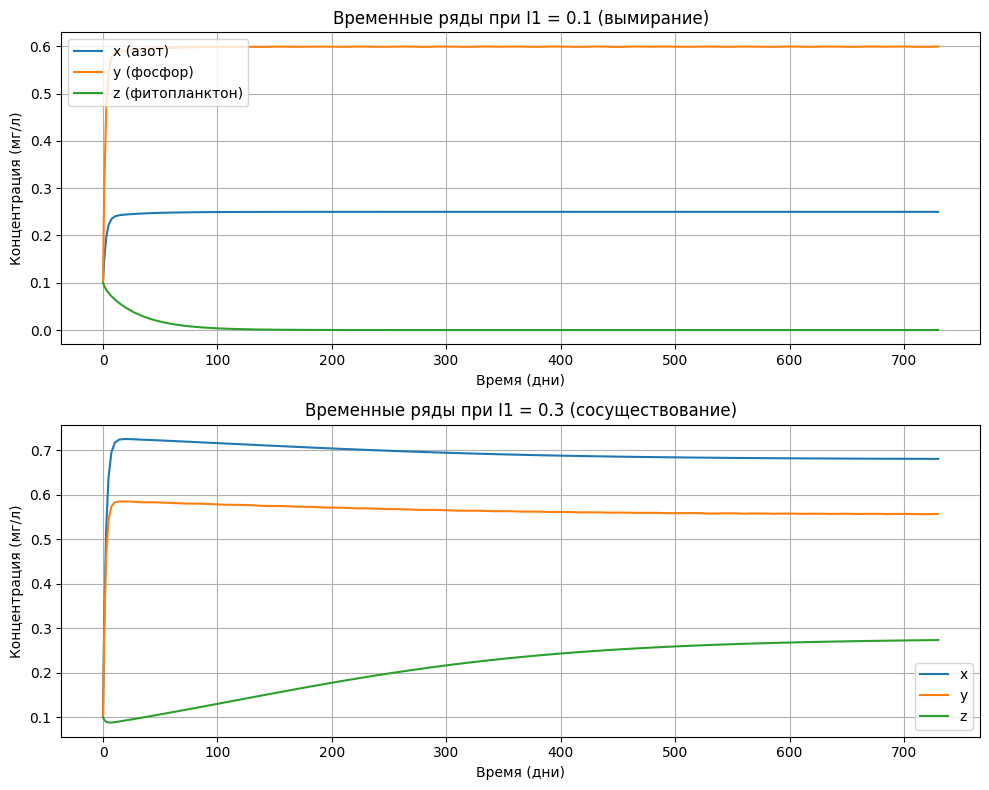

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

ax = axes[0]
ax.plot(sol1.t, sol1.y[0], label='x (азот)')
ax.plot(sol1.t, sol1.y[1], label='y (фосфор)')
ax.plot(sol1.t, sol1.y[2], label='z (фитопланктон)')
ax.set_title(f'Временные ряды при I1 = {I1_1} (вымирание)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(sol2.t, sol2.y[0], label='x')
ax.plot(sol2.t, sol2.y[1], label='y')
ax.plot(sol2.t, sol2.y[2], label='z')
ax.set_title(f'Временные ряды при I1 = {I1_2} (сосуществование)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

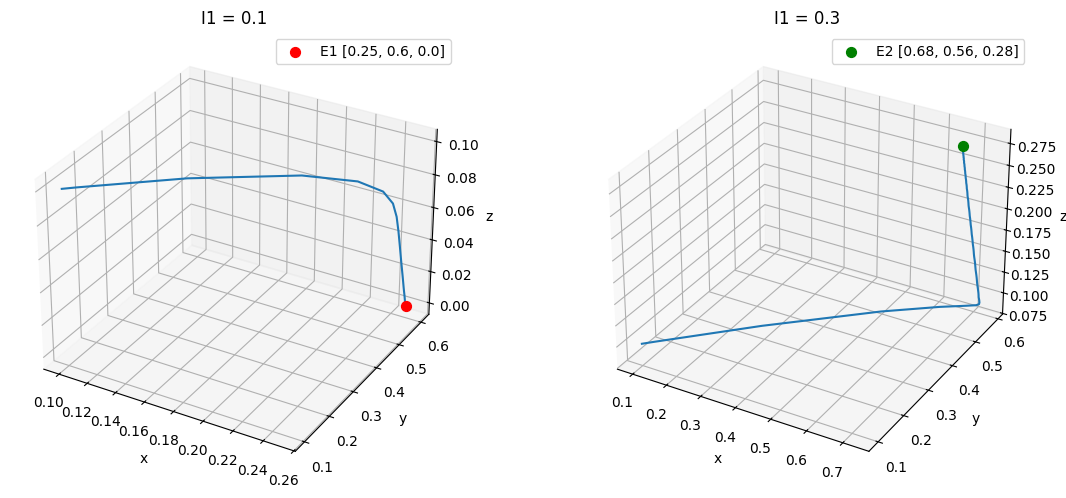

In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121, projection='3d')
ax.plot(sol1.y[0], sol1.y[1], sol1.y[2])
ax.scatter(E1[0], E1[1], E1[2], color='red', s=50, label=f"E1 {E1.astype(float).tolist()}")
ax.set_title(f'I1 = {I1_1}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

ax = fig.add_subplot(122, projection='3d')
ax.plot(sol2.y[0], sol2.y[1], sol2.y[2])
ax.scatter(E2[0], E2[1], E2[2], color='green', s=50, label=f"E2 {[round(f, 2) for f in E2.astype(float).tolist()]}")
ax.set_title(f'I1 = {I1_2}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

plt.tight_layout()
plt.show()

# ЧАСТЬ II. Синтез АКАР-управления

## Случай 1 — тривиальный АКАР: прямое управление фитопланктоном

Управление входит **аддитивно** в третье уравнение:

```
ẋ = I1 − b1·x − a1·x·z/(c1+x)
ẏ = I2 − b2·y − a2·y·z/(c2+y)
ż = e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z + u
```

- Шаг 1: `ψ = z − z*`, `z* = 50% от z в точке равновесия`.
- Шаг 2: `ψ̇ = −ψ/T`.
- Шаг 3: так как `∂ψ/∂x = 0`, `∂ψ/∂y = 0`, `∂ψ/∂z = 1`: `ψ̇ = ż = e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z + u`.
- Шаг 4: `e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z + u = −(z − z*)/T` ⟹
  **`u = −(z − z*)/T − e1·a1·x·z/(c1+x) − e2·a2·y·z/(c2+y) + m·z`**.

In [28]:
I1 = I1_2
z_target = 0.5 * E2[2]

print(f"I1 = {I1}")
print(f"z* = {z_target}")

T_1 = 0.5
T_2 = 1.0
T_3 = 1.5

def get_u(x, y, z, T):
    """
    Функция закона управления u(x, y, z).
    """
    return -(z - z_target) / T - e1 * a1 * x * z / (c1 + x) - e2 * a2 * y * z / (c2 + y) + m * z

def get_psi(z):
    return z - z_target

def ode_rhs_with_u(Y, T):
    """
    Правая часть системы (1) из статьи.
    Y = [x, y, z]
    """
    x, y, z = Y
    dx = I1 - b1 * x - a1 * x * z / (c1 + x)
    dy = I2 - b2 * y - a2 * y * z / (c2 + y)
    dz = e1 * a1 * x * z / (c1 + x) + e2 * a2 * y * z / (c2 + y) - m * z + get_u(x, y, z, T)
    return [dx, dy, dz]

I1 = 0.3
z* = 0.13860551247177036


In [29]:
Y0 = E2 # Начинаем управление с точки равновесия
t_span = (0, 8)
t_eval = np.linspace(0, 8, 128)

# T = 0.5
sol1 = solve_ivp(lambda t, Y: ode_rhs_with_u(Y, T_1), t_span, Y0, t_eval=t_eval)
u_1 = get_u(sol1.y[0], sol1.y[1], sol1.y[2], T_1)
psi_1 = get_psi(sol1.y[2])
print(sol1)
print(np.max(np.abs(u_1)))
print()

# T = 1.0
sol2 = solve_ivp(lambda t, Y: ode_rhs_with_u(Y, T_2), t_span, Y0, t_eval=t_eval)
u_2 = get_u(sol2.y[0], sol2.y[1], sol2.y[2], T_2)
psi_2 = get_psi(sol2.y[2])
print(sol2)
print(np.max(np.abs(u_2)))
print()

# T = 1.5
sol3 = solve_ivp(lambda t, Y: ode_rhs_with_u(Y, T_3), t_span, Y0, t_eval=t_eval)
u_3 = get_u(sol3.y[0], sol3.y[1], sol3.y[2], T_3)
psi_3 = get_psi(sol3.y[2])
print(sol3)
print(np.max(np.abs(u_3)))
print()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.299e-02 ...  7.937e+00  8.000e+00]
        y: [[ 6.797e-01  6.797e-01 ...  7.120e-01  7.120e-01]
            [ 5.566e-01  5.567e-01 ...  5.772e-01  5.772e-01]
            [ 2.772e-01  2.608e-01 ...  1.386e-01  1.386e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 56
     njev: 0
      nlu: 0
0.2772110249435408

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.299e-02 ...  7.937e+00  8.000e+00]
        y: [[ 6.797e-01  6.797e-01 ...  7.114e-01  7.115e-01]
            [ 5.566e-01  5.566e-01 ...  5.769e-01  5.769e-01]
            [ 2.772e-01  2.687e-01 ...  1.387e-01  1.387e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 44
     njev: 0
      nlu: 0
0.1386055124717704

  message: The solver successfully reached the end of the integration 

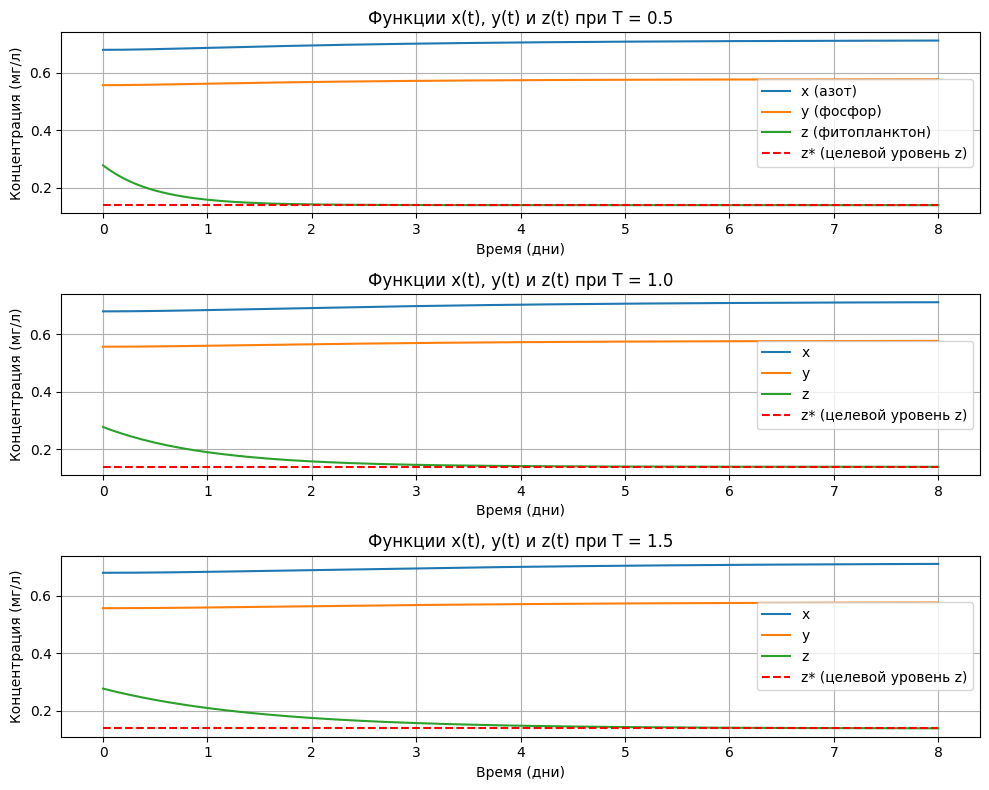

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

ax = axes[0]
ax.plot(sol1.t, sol1.y[0], label='x (азот)')
ax.plot(sol1.t, sol1.y[1], label='y (фосфор)')
ax.plot(sol1.t, sol1.y[2], label='z (фитопланктон)')
ax.plot([0, 8], [z_target, z_target], 'r--', label='z* (целевой уровень z)')
ax.set_title(f'Функции x(t), y(t) и z(t) при T = {T_1}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(sol2.t, sol2.y[0], label='x')
ax.plot(sol2.t, sol2.y[1], label='y')
ax.plot(sol2.t, sol2.y[2], label='z')
ax.plot([0, 8], [z_target, z_target], 'r--', label='z* (целевой уровень z)')
ax.set_title(f'Функции x(t), y(t) и z(t) при T = {T_2}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[2]
ax.plot(sol3.t, sol3.y[0], label='x')
ax.plot(sol3.t, sol3.y[1], label='y')
ax.plot(sol3.t, sol3.y[2], label='z')
ax.plot([0, 8], [z_target, z_target], 'r--', label='z* (целевой уровень z)')
ax.set_title(f'Функции x(t), y(t) и z(t) при T = {T_3}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

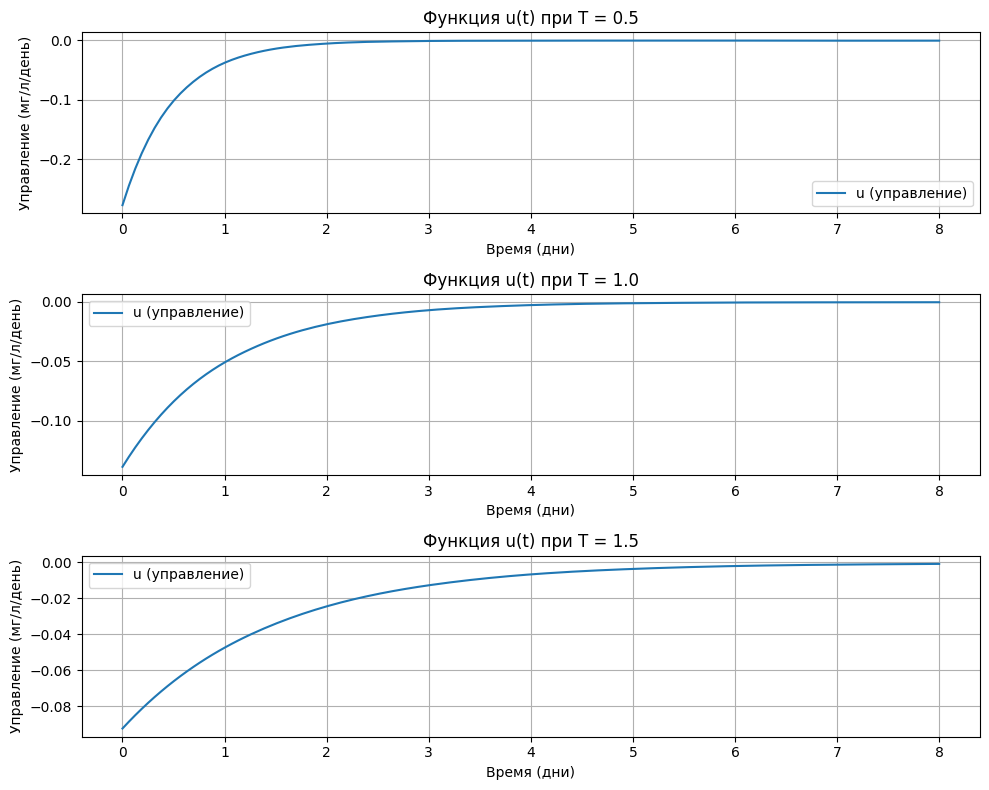

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

ax = axes[0]
ax.plot(sol1.t, u_1, label='u (управление)')
ax.set_title(f'Функция u(t) при T = {T_1}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Управление (мг/л/день)')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(sol2.t, u_2, label='u (управление)')
ax.set_title(f'Функция u(t) при T = {T_2}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Управление (мг/л/день)')
ax.legend()
ax.grid(True)

ax = axes[2]
ax.plot(sol3.t, u_3, label='u (управление)')
ax.set_title(f'Функция u(t) при T = {T_3}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Управление (мг/л/день)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

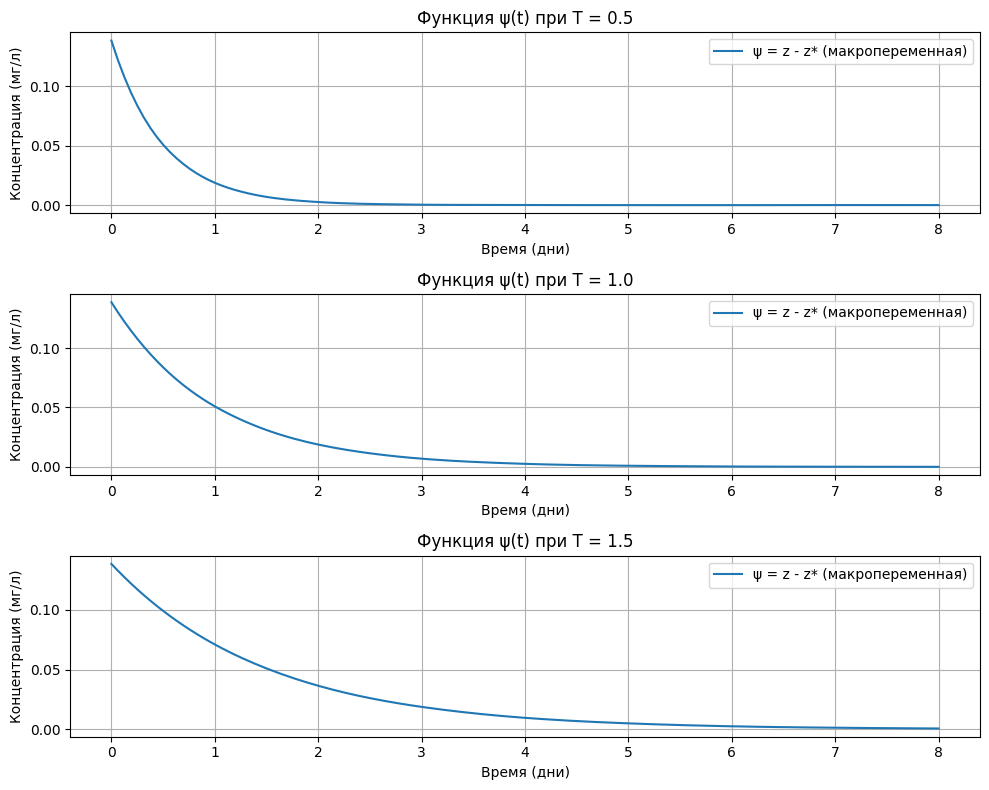

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

ax = axes[0]
ax.plot(sol1.t, psi_1, label='ψ = z - z* (макропеременная)')
ax.set_title(f'Функция ψ(t) при T = {T_1}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(sol2.t, psi_2, label='ψ = z - z* (макропеременная)')
ax.set_title(f'Функция ψ(t) при T = {T_2}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[2]
ax.plot(sol3.t, psi_3, label='ψ = z - z* (макропеременная)')
ax.set_title(f'Функция ψ(t) при T = {T_3}')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

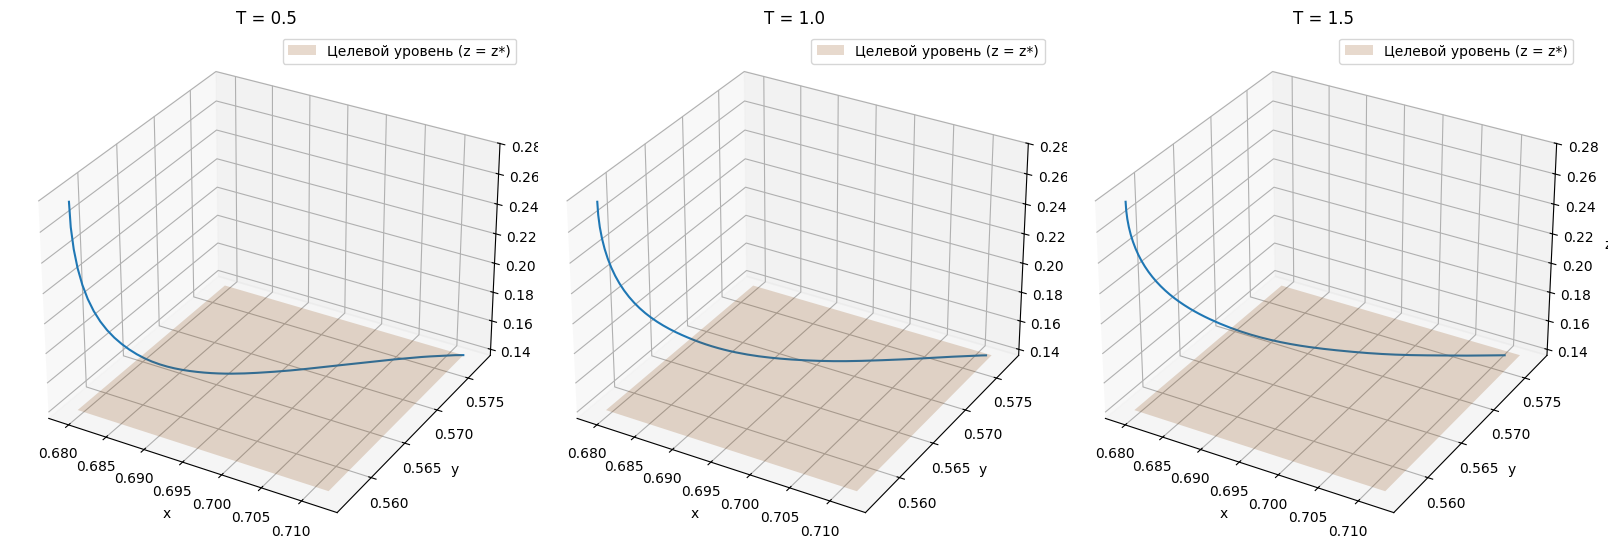

In [33]:
fig = plt.figure(figsize=(16, 8))

_X = np.array([ [E2[0], E2[0]], [sol1.y[0][-1], sol1.y[0][-1]] ])
_Y = np.array([ [E2[1], sol1.y[1][-1]], [E2[1], sol1.y[1][-1]] ])
_Z = np.array([ [ z_target, z_target ], [ z_target, z_target ] ])

ax = fig.add_subplot(131, projection='3d')
ax.plot(sol1.y[0], sol1.y[1], sol1.y[2])
ax.plot_surface(_X, _Y, _Z, alpha=0.2, label=f'Целевой уровень (z = z*)')
ax.set_title(f'T = {T_1}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

ax = fig.add_subplot(132, projection='3d')
ax.plot(sol2.y[0], sol2.y[1], sol2.y[2])
ax.plot_surface(_X, _Y, _Z, alpha=0.2, label=f'Целевой уровень (z = z*)')
ax.set_title(f'T = {T_2}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

ax = fig.add_subplot(133, projection='3d')
ax.plot(sol3.y[0], sol3.y[1], sol3.y[2])
ax.plot_surface(_X, _Y, _Z, alpha=0.2, label=f'Целевой уровень (z = z*)')
ax.set_title(f'T = {T_3}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

plt.tight_layout()
plt.show()

### Выаоды по случаю 1

#### 1. Реализация замкнутой системы

Начальные условия взяты из точки равновесия `E2` (при `I1 = 0.3`). Под действием управления система переходит из состояния с высокой биомассой `z ≈ 0.28` к целевому уровню `z* ≈ 0.139` за время порядка 5T (в соответствии с экспоненциальной динамикой макропеременной `ψ = z − z*`).

#### 2. Влияние параметра `T` на поведение системы

Параметр `T` определяет желаемую скорость сходимости макропеременной `ψ(t)` к нулю, так как задаётся уравнение `ψ̇ =−ψ/T`.
Исследованы три значения: `0.5`, `1.0` и `1.5`.

- При малом `T` (`0.5`) сходимость происходит быстрее всего, однако управляющее воздействие `u(t)` имеет наибольшую амплитуду (пик около `0.28` по модулю), что может быть нежелательно с практической точки зрения (например, при механическом удалении фитопланктона или применении альгицидов).
- При среднем `T` (`1.0`) скорость сходимости средня, амплитуда управления средняя (пик около `0.14` по модулю). Это компромисс между скоростью и величиной управляющего сигнала.
- При большом `T` (`1.5`) переход наиболее плавный, управление `|u(t)|` не превышает `0.1`, но процесс выхода на целевой уровень затягивается. Это может быть предпочтительно в экологических задачах, где резкие вмешательства нежелательны.

#### 3. Поведение макропеременной `ψ(t)`

Во всех трёх случаях `ψ(t)` монотонно убывает и стремится к нулю, что подтверждает корректность синтеза. Чем меньше `T`, тем быстрее `ψ → 0`, что согласуется с теорией АКАР.

#### 4. Фазовые траектории
На фазовых портретах видно, что траектория системы плавно выходит из исходной точки `E2` и достигает плоскости `z = z*`, причём при меньшем `T` траектория более «крутая» по `z`.


## Случай 2 — двухшаговый АКАР: управление по трофической базе

- Рчаг управления — **азот N**
- Тип управления — **аддитивное**

Управление входит **аддитивно** в первое уравнение:

```
ẋ = I1 − b1·x − a1·x·z/(c1+x) + u
ẏ = I2 − b2·y − a2·y·z/(c2+y)
ż = e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z
```

- Шаг 0: `ψ = z − z*`, `z* = 50% от z в точке равновесия`.
- Шаг 1: `ψ₂ = x − φ(x, y, z)`, `ψ₂ → 0` ⟹ `x → φ`.
- Шаг 2: `ψ̇₂ + ψ₂/T₁ = 0` ⟹ `ψ̇₂ = ẋ − dφ/dt = I1 − b1·x − a1·x·z/(c1+x) + u − dφ/dt` ⟹
  `u = −(x − φ)/T₁ − I1 + b1·x + a1·x·z/(c1+x) + dφ/dt`
- Шаг 3: `ψ̇ + ψ/T₂ = 0` ⟹ `ψ̇ = ż = e1·a1·φ·z/(c1+φ) + e2·a2·y·z/(c2+y) − m·z = −(z − z*)/T₂` ⟹
  `φ = c1·(m·z − e2·a2·y·z/(c2+y) − (z − z*)/T₂)/(e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂)`
- Шаг 4: `dφ/dx = 0`, `dφ/dy = −c1·c2·a1·a2·e1·e2·z·z/((e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂)^2·(c2+y)^2)`,
  `dφ/dx = −(c1·e1·a1·z*)/(T₂·(e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂)^2)` ⟹
  `dφ/dt = ẏ·dφ/dy + ż·dφ/dz = −((I2 − b2·y − a2·y·z/(c2+y))·e1·e2·a1·a2·c1·c2·z·z·T₂ + (e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z)·c1·e1·a1·z*·(c2+y)^2)/(T₂·(e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂)^2·(c2+y)^2)`

Итоговая функция управления:
**`u = −(x − c1·(m·z − e2·a2·y·z/(c2+y) − (z − z*)/T₂)/(e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂))/T₁ − I1 + b1·x + a1·x·z/(c1+x) − ((I2 − b2·y − a2·y·z/(c2+y))·e1·e2·a1·a2·c1·c2·z·z·T₂ + (e1·a1·x·z/(c1+x) + e2·a2·y·z/(c2+y) − m·z)·c1·e1·a1·z*·(c2+y)^2)/(T₂·(e1·a1·z − m·z + e2·a2·y·z/(c2+y) + (z − z*)/T₂)^2·(c2+y)^2)`**.

In [34]:
T1 = 4.0 # Параметры подобраны так, чтобы концентрация азота не падала ниже нуля
T2 = 7.0

def v2_get_psi(z):
    return z - z_target

def v2_get_phi(y, z):
    return c1 * (m * z - e2 * a2 * y * z / (c2 + y) - v2_get_psi(z) / T2) \
    / (e1 * a1 * z - m * z + e2 * a2 * y * z / (c2 + y) + v2_get_psi(z) / T2)

def v2_get_psi2(x, y, z):
    return x - v2_get_phi(y, z)

def v2_get_u(x, y, z):
    """
    Функция закона управления u(x, y, z).
    """
    d_phi = -((I2 - b2 * y - a2 * y * z / (c2 + y)) * e1 * e2 * a1 * a2 * c1 * c2 * z * z * T2 + \
              (e1 * a1 * x * z / (c1 + x) + e2 * a2 * y * z / (c2 + y) - m * z) * c1 * e1 * a1 * z_target * (c2 * y)**2) \
    / (T2 * (e1 * a1 * z - m * z + e2 * a2 * y * z / (c2 + y) + (z - z_target) / T2)**2 * (c2 + y)**2)
    return -v2_get_psi2(x, y, z) / T1 - I1 + b1 * x + a1 * x * z / (c1 + x) + d_phi

def v2_ode_rhs(Y):
    """
    Правая часть системы (1) из статьи.
    Y = [x, y, z]
    """
    x, y, z = Y
    dx = I1 - b1 * x - a1 * x * z / (c1 + x) + v2_get_u(x, y, z)
    dy = I2 - b2 * y - a2 * y * z / (c2 + y)
    dz = e1 * a1 * x * z / (c1 + x) + e2 * a2 * y * z / (c2 + y) - m * z
    return [dx, dy, dz]

In [35]:
Y0 = E2 # Начинаем управление с точки равновесия
t_span = (0, 60)
t_eval = np.linspace(0, 60, 6000)

sol = solve_ivp(lambda t, Y: v2_ode_rhs(Y), t_span, Y0, t_eval=t_eval)
psi2 = v2_get_psi2(sol.y[0], sol.y[1], sol.y[2])
u = v2_get_u(sol.y[0], sol.y[1], sol.y[2])
psi = v2_get_psi(sol.y[2])
print(sol)
print()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-02 ...  5.999e+01  6.000e+01]
        y: [[ 6.797e-01  6.778e-01 ...  6.611e-01  6.611e-01]
            [ 5.566e-01  5.566e-01 ...  5.774e-01  5.774e-01]
            [ 2.772e-01  2.772e-01 ...  1.386e-01  1.386e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 92
     njev: 0
      nlu: 0



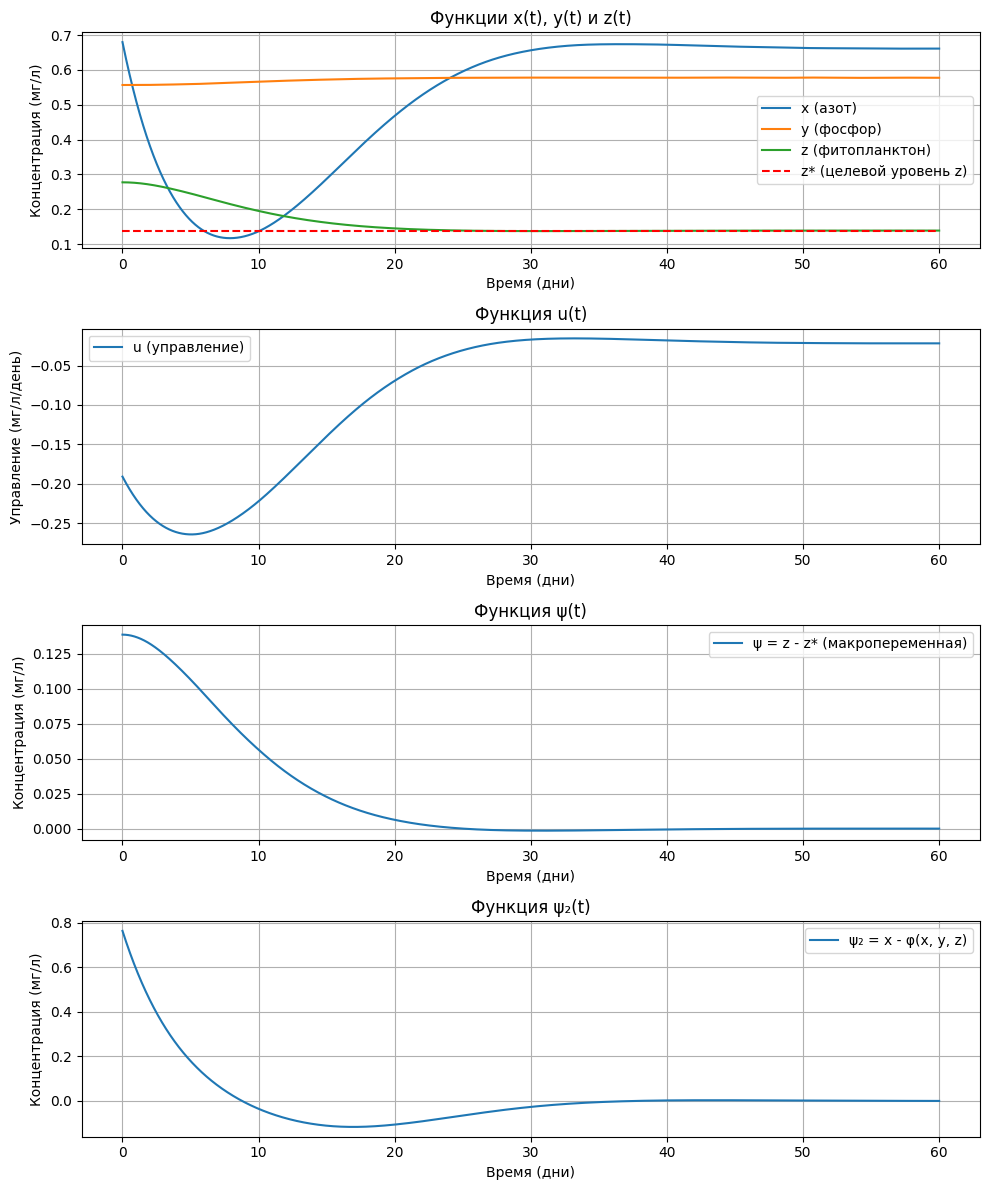

In [36]:
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

ax = axes[0]
ax.plot(sol.t, sol.y[0], label='x (азот)')
ax.plot(sol.t, sol.y[1], label='y (фосфор)')
ax.plot(sol.t, sol.y[2], label='z (фитопланктон)')
ax.plot([0, 60], [z_target, z_target], 'r--', label='z* (целевой уровень z)')
ax.set_title(f'Функции x(t), y(t) и z(t)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(sol.t, u, label='u (управление)')
ax.set_title(f'Функция u(t)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Управление (мг/л/день)')
ax.legend()
ax.grid(True)

ax = axes[2]
ax.plot(sol.t, psi, label='ψ = z - z* (макропеременная)')
ax.set_title(f'Функция ψ(t)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

ax = axes[3]
ax.plot(sol.t, psi2, label='ψ₂ = x - φ(x, y, z)')
ax.set_title(f'Функция ψ₂(t)')
ax.set_xlabel('Время (дни)')
ax.set_ylabel('Концентрация (мг/л)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

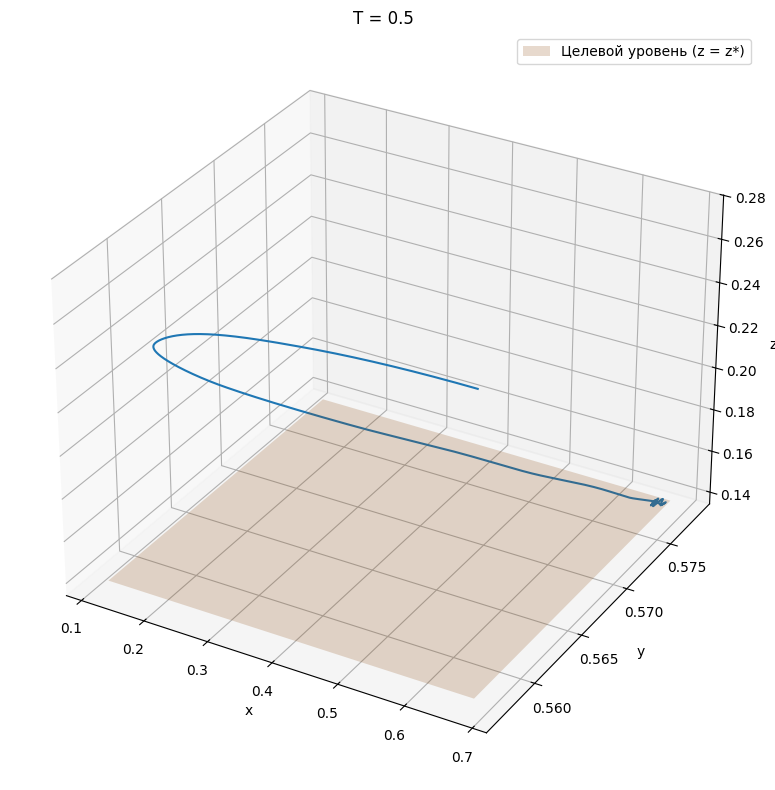

In [37]:
fig = plt.figure(figsize=(8, 8))

_X = np.array([ [ np.min(sol.y[0]) ] * 2, [ np.max(sol.y[0]) ] * 2 ])
_Y = np.array([ [ np.min(sol.y[1]) ] * 2, [ np.max(sol.y[1]) ] * 2 ]).T
_Z = np.array([[ z_target, z_target ], [ z_target, z_target ]])

ax = fig.add_subplot(111, projection='3d')
ax.plot(sol.y[0], sol.y[1], sol.y[2])
ax.plot_surface(_X, _Y, _Z, alpha=0.2, label=f'Целевой уровень (z = z*)')
ax.set_title(f'T = {T_1}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

plt.tight_layout()
plt.show()

### Выводы по случаю 2

#### 1. Реализация замкнутой системы

Двухшаговый АКАР-регулятор с аддитивным управлением по азоту был успешно реализован и протестирован. Начальные условия взяты из точки равновесия `E2` (`I1 = 0.3`). Под действием управления концентрация фитопланктона `z(t)` плавно снижается от `z ≈ 0.28` до целевого уровня `z* ≈ 0.139` за время порядка 40 дней. При этом концентрации биогенов `x(t)` и `y(t)` также изменяются: `x` уменьшается, а `y` возрастает, выходя на новые стационарные значения. Важно, что благодаря подбору параметров `T1 = 4.0` и `T2 = 7.0` концентрация азота остаётся положительной на всём интервале интегрирования, что устраняет проблему, возникавшую при меньших значениях параметров.

#### 2. Влияние параметров `T1` и `T2` на поведение системы

Параметры `T1` (скорость сходимости вспомогательной макропеременной `ψ₂ = x − φ`) и `T2` (скорость сходимости основной макропеременной `ψ = z − z*`) определяют динамику замкнутой системы. В ходе численных экспериментов установлено:

- При малых `T1` и `T2` управление становится слишком агрессивным, что приводит к отрицательным значениям x и потере физического смысла концентрации.
- При умеренно больших значениях (`T1 = 4.0` и `T2 = 7.0`) процесс протекает плавно, управляющее воздействие `u(t)` имеет ограниченную амплитуду (пик около `0.27` по модулю), а все переменные остаются в физически допустимых пределах.
- Дальнейшее увеличение `T1` и `T2` замедляет сходимость, но сохраняет устойчивость и положительность.

#### 3. Поведение макропеременных `ψ(t)` и `ψ₂(t)`

Графики макропеременных показывают стремление к нулю (`ψ(t)` монотонно убывает, а `ψ₂(t)` просто стремится к нулю). Это свидетельствует о том, что `x` успешно отслеживает требуемое значение `φ`, обеспечивая желаемую динамику для `z`, что подтверждает корректность двухшагового метода и достижение цели управления.

#### 4. Фазовые траектории

На фазовом портрете в пространстве `(x,y,z)` видно, что траектория плавно выходит из начальной точки `E2` и выходит на поверхность `z = z*`, после чего устанавливается новое стационарное состояние.


## Сравнение прямого управления и управления по трофической базе